# Project 02 (medium) — reference solution: bootstrap and permutation test

**Scenario:** an A/B test, variant B of the product page against variant A, 4,000
visitors each. Two questions: do more visitors buy with B (conversion rate), and do
buyers spend more money with B (order value)? Both are answered without a single
distributional formula — with the bootstrap and a permutation test, built by hand.

**This is the fully worked solution.** All cells have been executed. The data are
synthetic with a known truth, revealed in section 4.

**Reference to the script:** sections 3.1 and 3.2, plus module 02 section 3.1.

## 1. The data

- `conv_a`, `conv_b`: True/False per visitor — did they buy?
- `value_a`, `value_b`: order values of the buyers in EUR (buyers only!)

Take a quick look at the data (the EDA reflex from module 02): how many purchases,
which rates, what do the order values look like?

A: 186 purchases out of 4000 (4.65%)
B: 213 purchases out of 4000 (5.33%)
Median order value: A 48.92 EUR, B 61.21 EUR


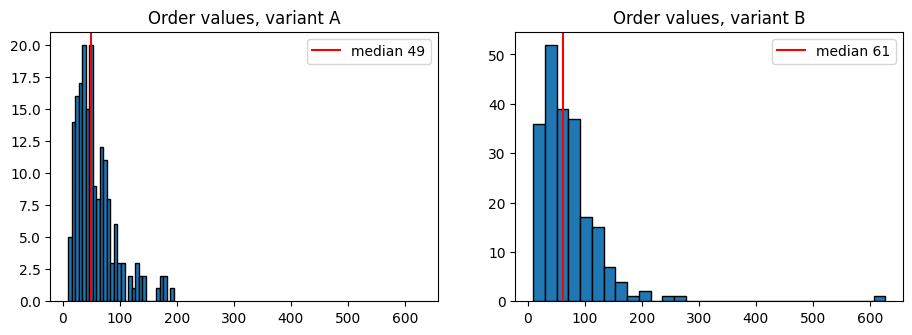

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)   # data seed — do NOT change, otherwise the checks break

N_A = N_B = 4000
conv_a = rng.random(N_A) < 0.048          # (the true rates are given at the end of the notebook)
conv_b = rng.random(N_B) < 0.052
value_a = rng.lognormal(np.log(50), 0.6, conv_a.sum())
value_b = rng.lognormal(np.log(56), 0.6, conv_b.sum())

print(f"A: {conv_a.sum()} purchases out of {N_A} ({conv_a.mean():.2%})")
print(f"B: {conv_b.sum()} purchases out of {N_B} ({conv_b.mean():.2%})")
print(f"Median order value: A {np.median(value_a):.2f} EUR, B {np.median(value_b):.2f} EUR")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5), sharex=True)
for ax, values, name in [(axes[0], value_a, "A"), (axes[1], value_b, "B")]:
    ax.hist(values, bins=30, edgecolor="black")
    ax.axvline(np.median(values), color="red", label=f"median {np.median(values):.0f}")
    ax.set_title(f"Order values, variant {name}"); ax.legend()
plt.show()

**Finding:** right-skewed order values (typical for amounts of money!) → the
**median** is the right statistic (module 02, script 1.3). But: for the standard error
of the median there is no formula as convenient as $s/\sqrt{n}$ for the mean.
Time for the bootstrap.

## 2. Bootstrap: how uncertain is our median?

**Idea (script 3.2):** we have only ONE sample. The bootstrap pretends it is the whole
population: we draw from it many new samples of the same size **with replacement** and
compute the median each time. The spread of these bootstrap medians shows how strongly
the median fluctuates from sample to sample.

**Task:** implement `bootstrap_distribution(values, statistic, n_boot)`:
draw a sample of length `len(values)` with replacement `n_boot` times
(`rng_boot.choice(values, size=len(values))` — `replace=True` is the default) and apply
`statistic` to it. Return a numpy array.

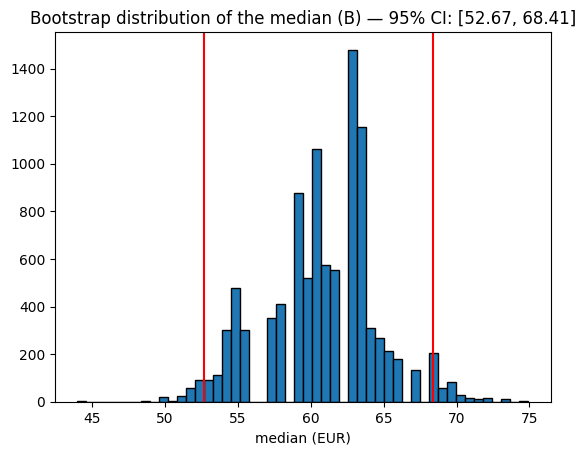

True


In [2]:
rng_boot = np.random.default_rng(1)   # a separate seed for the resampling procedures

def bootstrap_distribution(values, statistic, n_boot=10_000):
    """Bootstrap: n_boot statistics from samples drawn with replacement."""
    results = np.empty(n_boot)
    for i in range(n_boot):
        sample = rng_boot.choice(values, size=len(values))
        results[i] = statistic(sample)
    return results

boot_medians_b = bootstrap_distribution(value_b, np.median)
ci_low, ci_high = np.percentile(boot_medians_b, [2.5, 97.5])

plt.hist(boot_medians_b, bins=50, edgecolor="black")
plt.axvline(ci_low, color="red"); plt.axvline(ci_high, color="red")
plt.title(f"Bootstrap distribution of the median (B) — 95% CI: [{ci_low:.2f}, {ci_high:.2f}]")
plt.xlabel("median (EUR)"); plt.show()

# Mini check: the CI should lie roughly in [52, 69] and be about 10-16 EUR wide
print(50 < ci_low < 58 and 63 < ci_high < 72)

**Reading:** "the median of B is about 61 EUR; plausible values (95 % CI) lie
between about 53 and 68 EUR." The uncertainty is considerable — after all we only have
about 200 purchases. Without the bootstrap one would probably have believed the point
value of 61.21 blindly.

**Task (transfer):** compute the 95 % bootstrap CI for the **difference of the medians**
(B − A). Hint: in every bootstrap round draw from *both* groups and store the difference
of medians. Does 0 lie in the interval?

In [3]:
def bootstrap_median_difference(a, b, n_boot=10_000):
    diffs = np.empty(n_boot)
    for i in range(n_boot):
        diffs[i] = (np.median(rng_boot.choice(b, size=len(b)))
                    - np.median(rng_boot.choice(a, size=len(a))))
    return diffs

diff_boot = bootstrap_median_difference(value_a, value_b)
lo, hi = np.percentile(diff_boot, [2.5, 97.5])
print(f"observed difference: {np.median(value_b) - np.median(value_a):.2f} EUR")
print(f"95% CI of the difference: [{lo:.2f}, {hi:.2f}] — contains 0: {lo <= 0 <= hi}")

observed difference: 12.29 EUR
95% CI of the difference: [3.49, 20.47] — contains 0: False


## 3. Permutation test: could this be chance?

The CI of the difference already suggests that B is better. Now the formal test.

**Idea (script 3.2):** under the null hypothesis "B has no effect", group membership is
meaningless — then one would be allowed to shuffle the labels arbitrarily. So: all values
into one pot, randomly redistribute onto two groups, compute the difference — 10,000 times.
The **p-value** is the share of shuffled differences that are (in absolute value) at
least as large as the observed one.

**Task:** implement `permutation_test(a, b, statistic)` for the difference
`statistic(b_shuffled) - statistic(a_shuffled)` and apply it to the **medians of the
order values**.

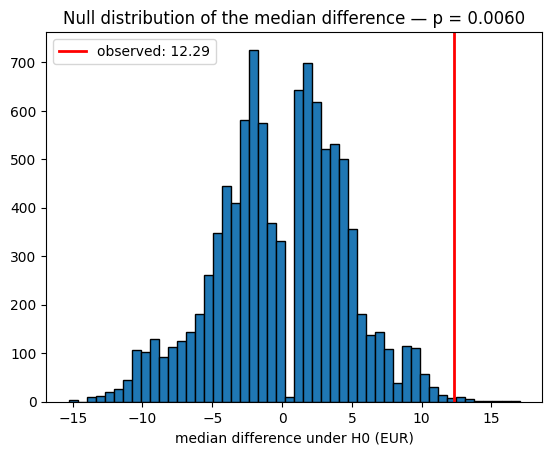

True


In [4]:
def permutation_test(a, b, statistic, n_perm=10_000):
    """Returns (observed_difference, p_value, null_distribution)."""
    observed = statistic(b) - statistic(a)
    pool = np.concatenate([a, b])
    null = np.empty(n_perm)
    for i in range(n_perm):
        shuffled = rng_boot.permutation(pool)
        null[i] = statistic(shuffled[len(a):]) - statistic(shuffled[:len(a)])
    p = float((np.abs(null) >= abs(observed)).mean())
    return observed, p, null

obs, p, null = permutation_test(value_a, value_b, np.median)
plt.hist(null, bins=50, edgecolor="black")
plt.axvline(obs, color="red", linewidth=2, label=f"observed: {obs:.2f}")
plt.title(f"Null distribution of the median difference — p = {p:.4f}")
plt.xlabel("median difference under H0 (EUR)"); plt.legend(); plt.show()

# Mini check: clearly significant
print(p < 0.02)

**Reading:** if B had no effect, a median difference of about 12 EUR would be
extremely unlikely (p about 0.005). **Buyers spend significantly more with B.**

**Task:** now the same machinery for the **conversion rate**:
`permutation_test(conv_a, conv_b, np.mean)` (the mean of True/False values is the rate!).
What comes out?

In [5]:
obs_c, p_c, null_c = permutation_test(conv_a, conv_b, np.mean)
print(f"difference of the conversion rates: {obs_c:.4f} ({obs_c:.2%} points)")
print(f"p-value: {p_c:.3f}")

# Mini check: NOT significant
print(p_c > 0.05)

difference of the conversion rates: 0.0067 (0.67% points)
p-value: 0.187
True


## 4. The resolution — and the most important lesson

Time to reveal the **true** parameters from the data cell:

| Quantity | Truth (generator) | Test result |
|--|--|--|
| Conversion rate | A: 4.8 %, B: 5.2 % — **B really is better!** | p about 0.18 → not significant |
| Median order value | A: 50 EUR, B: 56 EUR — B really is better | p about 0.005 → significant |

The conversion effect **exists**, but the test **did not find it**: at rates around 5 %
and a difference of 0.4 percentage points, 2 x 4,000 visitors are simply not enough
(too little **power**, script 3.1 — such effects need tens of thousands of visitors per
group).

**The lessons:**
1. **"Not significant" does NOT mean "no effect"** — often it only means "too little data".
2. That is why the power analysis is done **before** the test: had one calculated that
   2 x 4,000 visitors could never suffice for the expected effect, one could have saved
   this part of the test (or let it run longer).
3. And conversely: the observed median difference (12.29 EUR) **overestimates** the true
   one (6 EUR) — even significant effects carry noise; therefore always report the
   confidence interval as well (is the true value of 6 inside it? check!).

**Closing task:** formulate a recommendation for the product team in 3 sentences.
(A reference answer is in the solution.)

<details><summary>Reference recommendation</summary>

Variant B clearly increases the order value of buyers (median +12 EUR observed, 95 % CI
about +3 to +21 EUR) — that is statistically solid. Whether B also improves the conversion
rate cannot be judged at this sample size (p = 0.18 with a very small expected effect);
for that the test would have to be repeated with markedly more visitors or a longer run
time. Recommendation: roll out B (the gain in order value is secure) and measure the
conversion effect in a follow-up test of larger dimensions.
</details>

## Done — what you can do now

- build bootstrap confidence intervals for arbitrary statistics (differences included)
- implement permutation tests and *really* understand p-values
  (you have seen the null distribution with your own eyes)
- take power seriously: not significant is not the same as no effect
- formulate results as a recommendation for action

**Bonus tasks:**
1. Repeat the conversion permutation test with 2 x 40,000 visitors (copy and adapt the
   data cell) — is the effect found now?
2. Compare your bootstrap CI for the **mean** of `value_b` with the formula variant
   $\bar{x} \pm 1.96 \cdot s/\sqrt{n}$ — how close are they?
3. `scipy.stats.mannwhitneyu(value_a, value_b)` is a classical rank test for the same
   question — compare its p-value with your permutation test.